# ⚙️ Automated Reporting Pipeline — Data to Report Workflow

This project demonstrates how to automate the entire data reporting process — from raw data ingestion to generating a formatted business report automatically.  
It simulates a real-world *data-to-report* workflow that companies use to save time and reduce manual reporting effort.
### 🎯 Objective
To design a workflow that:
1. Extracts data automatically,
2. Cleans and aggregates it,
3. Generates visual and tabular reports,
4. Exports them as Excel/PDF files ready for business review.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from io import BytesIO

# Load data
df = pd.read_csv("/content/train.csv")

# Clean column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Convert dates
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)

# Quick check
df.head(3)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


### 📦 Data Extraction & Cleaning
The dataset (E-Commerce sales data) is loaded automatically from a CSV file.  
It contains customer, region, category, and sales details — ideal for business performance reporting.


### 🧹 Transformation & KPI Calculation
The pipeline creates new columns such as `year` and `month`, then calculates monthly sales to identify trends and prepare summaries for reporting.


In [2]:
# Fill missing postal codes
df["postal_code"].fillna(df["postal_code"].mode()[0], inplace=True)

# Create year and month fields
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()

# Calculate monthly KPIs
monthly_sales = df.groupby(["year", "month"])["sales"].sum().reset_index()
monthly_sales.tail()


/tmp/ipython-input-1828136747.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["postal_code"].fillna(df["postal_code"].mode()[0], inplace=True)


,year,month,sales
43,2018,March,58863.4128
44,2018,May,43825.9822
45,2018,November,117938.1550
46,2018,October,77448.1312
47,2018,September,86152.8880


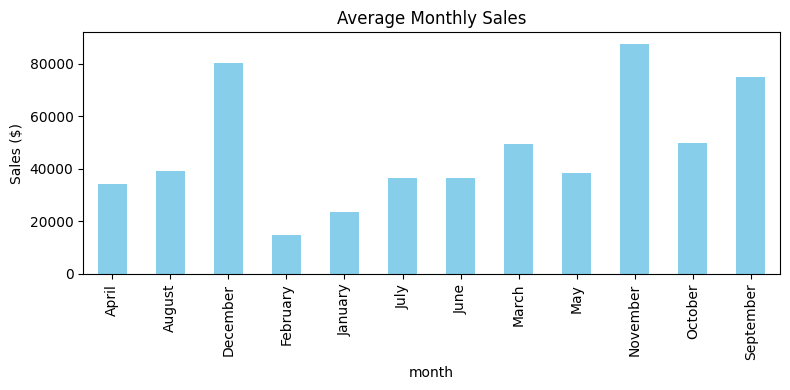

In [3]:
plt.figure(figsize=(8,4))
monthly_sales.groupby("month")["sales"].mean().plot(kind="bar", color="skyblue")
plt.title("Average Monthly Sales")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("monthly_sales_chart.png")
plt.show()


### 📊 Visualization
To make the report visually insightful, a simple bar chart is generated showing average monthly sales.  
This visual will later be included in the automated report.


In [5]:
output_path = "/content/automated_business_report.xlsx"

with pd.ExcelWriter(output_path) as writer:
    # Write summary sheets
    df.describe().to_excel(writer, sheet_name="Data_Summary")
    monthly_sales.to_excel(writer, sheet_name="Monthly_Sales", index=False)

print(f"✅ Automated report generated: {output_path}")


✅ Automated report generated: /content/automated_business_report.xlsx


### 🧾 Report Generation
Finally, an automated Excel report is created containing:
- Data summary (descriptive stats)
- Monthly sales trends
- Visual charts (optional)

This report can be scheduled to run daily or weekly using tools like Power Automate or system schedulers.


In [7]:
!ls -lh /content/automated_business_report.xlsx


-rw-r--r-- 1 root root 6.9K Nov 11 06:17 /content/automated_business_report.xlsx


## 🧾 Summary

This project automates repetitive reporting tasks using Python.  
It reflects a practical business scenario where teams generate periodic performance reports automatically.

### ✅ Key Takeaways
- Automated workflow from data to final report  
- Practical example of analytics automation  
- Scalable and reusable approach  

### 🚀 Next Steps
- Integrate email delivery for reports  
- Add Power BI connection for dynamic refresh  
- Automate scheduling using Airflow or Cron  

---

>
